<a href="https://colab.research.google.com/github/harshitha020505/DLLAB/blob/main/DLLAB9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

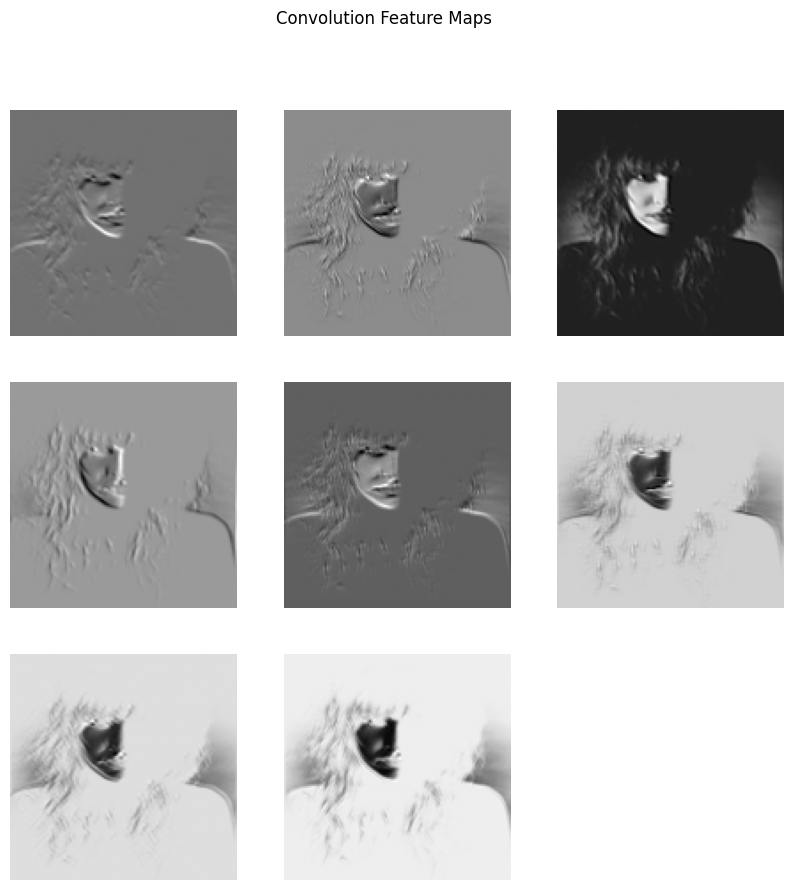

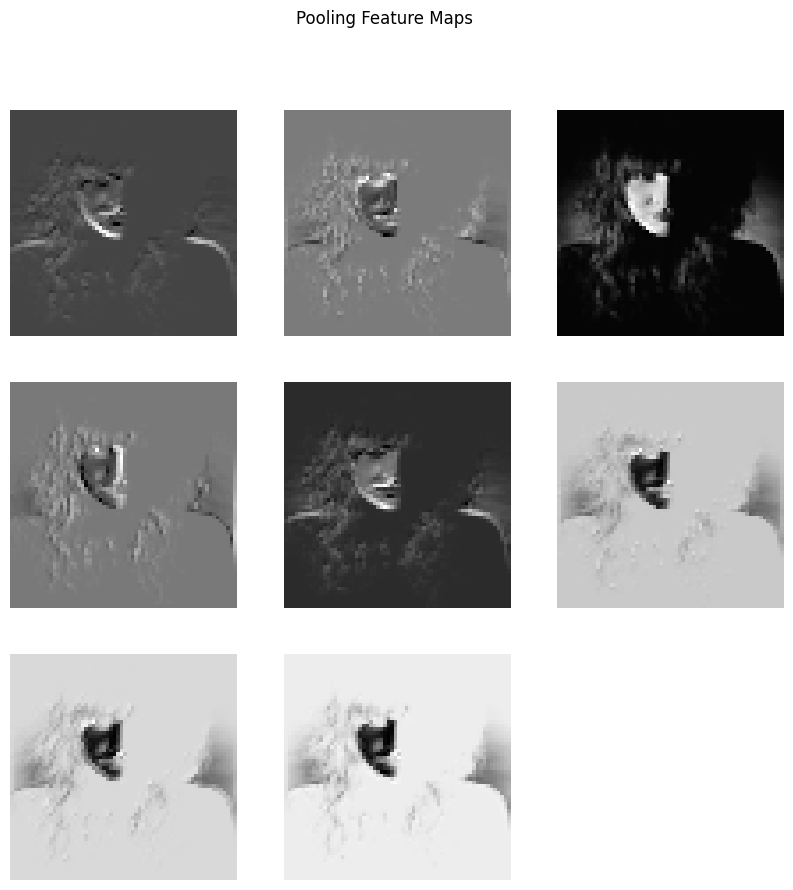

In [4]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

image = Image.open("sample.jpeg").convert('RGB')

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

img_tensor = transform(image).unsqueeze(0)

conv = nn.Conv2d(3, 8, 3, 1, 1)
pool = nn.MaxPool2d(2, 2)

conv_output = conv(img_tensor)
pool_output = pool(conv_output)

def show_feature_maps(feature_map, title):
    feature_map = feature_map.squeeze(0)
    num_maps = feature_map.shape[0]

    plt.figure(figsize=(10, 10))
    for i in range(num_maps):
        plt.subplot(3, 3, i+1)
        plt.imshow(feature_map[i].detach().numpy(), cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_feature_maps(conv_output, "Convolution Feature Maps")
show_feature_maps(pool_output, "Pooling Feature Maps")